---
## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Cross-validation & tuning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_style('whitegrid')
%matplotlib inline

print('All imports successful!')

All imports successful!


---
## 2. Load Data

In [4]:
train_df = pd.read_csv('../data/train.csv')
test_df  = pd.read_csv('../data/test.csv')

# Combine for joint feature engineering
data_df = pd.concat([train_df, test_df], ignore_index=True)

print(f'Train shape: {train_df.shape}')
print(f'Test shape:  {test_df.shape}')
train_df.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Dataset columns:**
- `Survived` — target (0=Died, 1=Survived)
- `Pclass` — ticket class (1=Upper, 2=Middle, 3=Lower)
- `Name`, `Sex`, `Age`
- `SibSp` — # siblings/spouses aboard
- `Parch` — # parents/children aboard
- `Ticket`, `Fare`, `Cabin`
- `Embarked` — port (C=Cherbourg, Q=Queenstown, S=Southampton)

---
## 3. Initial Exploration (EDA)

**What is EDA?** Exploratory Data Analysis means looking at the data from many angles to understand its structure, find patterns, and form hypotheses before building a model.

**Key questions for Titanic:**
- Who survived? What patterns exist?
- Which features have missing values?
- How does each feature relate to survival?

In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
# Missing value analysis
missing     = train_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[missing > 0]

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [9]:
# Overall survival rate
print(f"Overall survival rate: {train_df['Survived'].mean():.2%}")
print(f"Died: {(train_df['Survived']==0).sum()} | Survived: {(train_df['Survived']==1).sum()}")

Overall survival rate: 38.38%
Died: 549 | Survived: 342


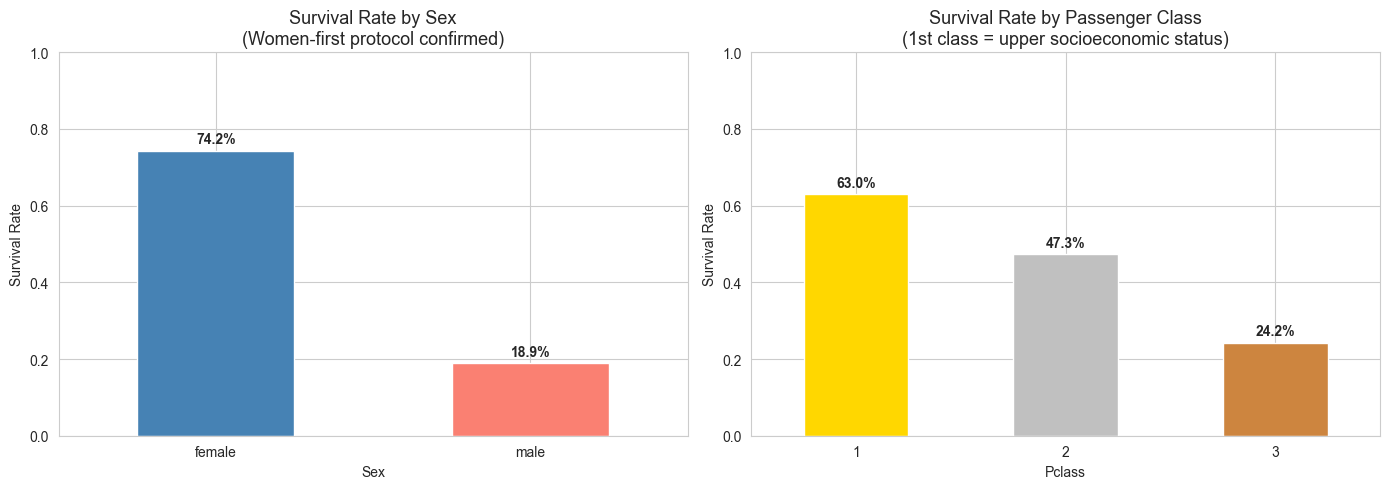

INSIGHT: Female survival 74% vs male 19% — Sex is the single strongest feature.
INSIGHT: 1st class survived at 63% vs 24% for 3rd class — wealth bought access to lifeboats.


In [11]:
# Survival by Sex and Pclass
# HYPOTHESIS: Women and children were prioritized ('women and children first' protocol)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_surv = train_df.groupby('Sex')['Survived'].mean()
sex_surv.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], rot=0)
axes[0].set_title('Survival Rate by Sex\n(Women-first protocol confirmed)', fontsize=13)
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
for i, v in enumerate(sex_surv):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

pclass_surv = train_df.groupby('Pclass')['Survived'].mean()
pclass_surv.plot(kind='bar', ax=axes[1], color=['gold', 'silver', 'peru'], rot=0)
axes[1].set_title('Survival Rate by Passenger Class\n(1st class = upper socioeconomic status)', fontsize=13)
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(pclass_surv):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("INSIGHT: Female survival 74% vs male 19% — Sex is the single strongest feature.")
print("INSIGHT: 1st class survived at 63% vs 24% for 3rd class — wealth bought access to lifeboats.")

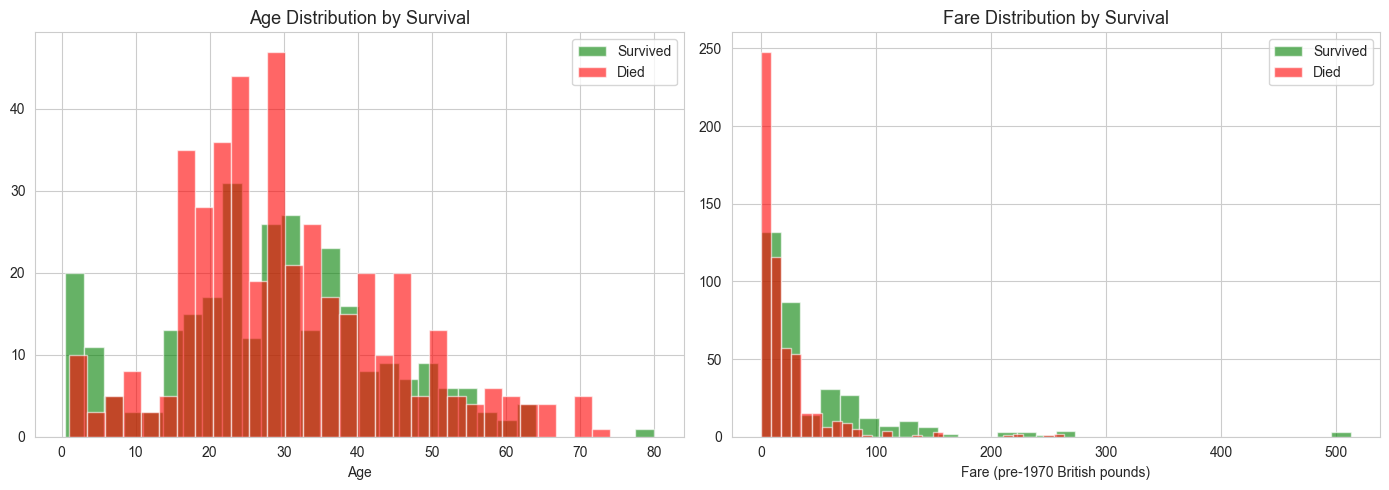

INSIGHT: Children under ~9 had notably higher survival — 'children first' in practice.
INSIGHT: Higher fare strongly correlates with survival — same information as Pclass but more granular.
INSIGHT: Age has 177 missing values — needs smart imputation.


In [12]:
# Age and Fare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df[train_df['Survived']==1]['Age'].dropna().hist(ax=axes[0], bins=30, alpha=0.6, color='green', label='Survived')
train_df[train_df['Survived']==0]['Age'].dropna().hist(ax=axes[0], bins=30, alpha=0.6, color='red',   label='Died')
axes[0].set_title('Age Distribution by Survival', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].legend()

train_df[train_df['Survived']==1]['Fare'].hist(ax=axes[1], bins=30, alpha=0.6, color='green', label='Survived')
train_df[train_df['Survived']==0]['Fare'].hist(ax=axes[1], bins=30, alpha=0.6, color='red',   label='Died')
axes[1].set_title('Fare Distribution by Survival', fontsize=13)
axes[1].set_xlabel('Fare (pre-1970 British pounds)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("INSIGHT: Children under ~9 had notably higher survival — 'children first' in practice.")
print("INSIGHT: Higher fare strongly correlates with survival — same information as Pclass but more granular.")
print(f"INSIGHT: Age has {train_df['Age'].isnull().sum()} missing values — needs smart imputation.")

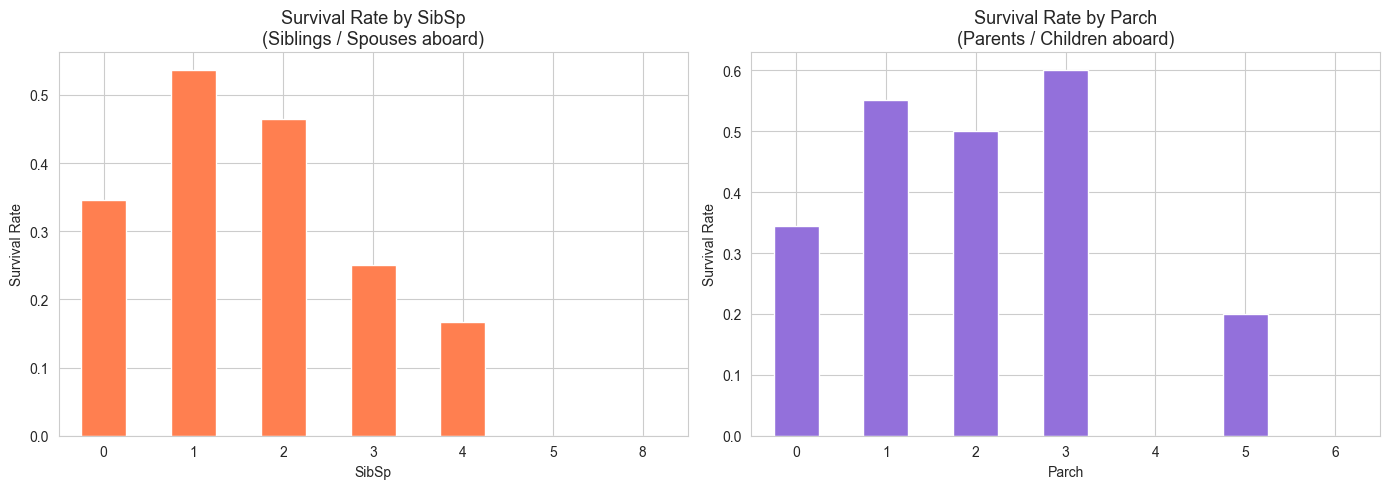

INSIGHT: Solo travelers (0 family) had lower survival — no one to help them find lifeboats.
INSIGHT: Small families (1–3) survived better. Very large families had coordination problems.
ACTION: Combine SibSp + Parch into a single Family_Size feature.


In [13]:
# Family features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df.groupby('SibSp')['Survived'].mean().plot(kind='bar', ax=axes[0], rot=0, color='coral')
axes[0].set_title('Survival Rate by SibSp\n(Siblings / Spouses aboard)', fontsize=13)
axes[0].set_ylabel('Survival Rate')

train_df.groupby('Parch')['Survived'].mean().plot(kind='bar', ax=axes[1], rot=0, color='mediumpurple')
axes[1].set_title('Survival Rate by Parch\n(Parents / Children aboard)', fontsize=13)
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

print("INSIGHT: Solo travelers (0 family) had lower survival — no one to help them find lifeboats.")
print("INSIGHT: Small families (1–3) survived better. Very large families had coordination problems.")
print("ACTION: Combine SibSp + Parch into a single Family_Size feature.")

## 4. Feature Engineering

**What is Feature Engineering?** Using domain knowledge to create new features from raw data that help the model find patterns it couldn't find on its own.

**Rule:** Always engineer features on the combined train+test dataset (`data_df`) so transformations are consistent. Never fit encoders or imputers on test data alone.

Features that **help** (from expert analysis of this dataset):
- Title, Family Size, Family Survival Rate, Age/Fare Bins, Name Length, Ticket Frequency

Features that **do NOT help** (confirmed by experts):
- `Embarked` — port of embarkation has no meaningful survival signal
- Raw `Cabin` / `Has_Cabin` binary — too noisy
- `Deck` from cabin letter — also too noisy

### 4.1 Title — Social Status + Gender + Age Group in One Feature

**Why?** A passenger's title encodes gender, age group, and social class simultaneously:
- `Master` = boy under ~15 → high survival
- `Miss` / `Mrs` = female → high survival  
- `Mr` = adult male → low survival
- `Royal` = elite class → resources and connections

This is more informative than Sex alone because it also captures age group.

In [14]:
# Extract title using regex — looks for a word followed by a dot
data_df['Title'] = data_df['Name'].str.extract('([A-Za-z]+)\.', expand=True)
print('All unique titles found:')
print(data_df['Title'].value_counts())

All unique titles found:
Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Ms            2
Major         2
Mlle          2
Don           1
Mme           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64


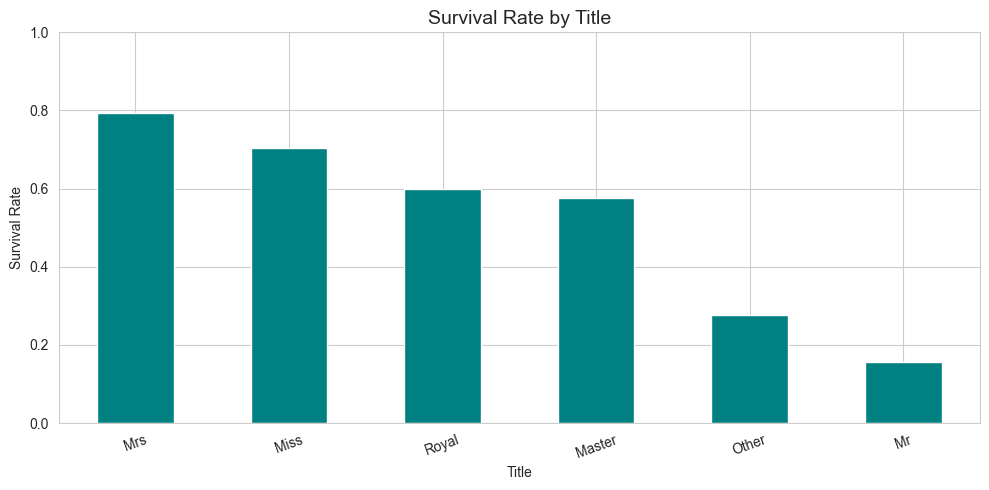

INSIGHT: Royal/Mrs/Miss have 70–100% survival. Mr has ~16%.
INSIGHT: Master (young boys) survived at ~57% — much better than adult men.


In [15]:
# Map rare/foreign titles to standard groups
title_mapping = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',        # French equivalents
    'Major': 'Other', 'Col': 'Other', 'Dr': 'Other',   # Professional titles
    'Rev': 'Other',   'Capt': 'Other',
    'Jonkheer': 'Royal', 'Sir': 'Royal', 'Lady': 'Royal',
    'Don': 'Royal',   'Countess': 'Royal', 'Dona': 'Royal'
}
data_df['Title'] = data_df['Title'].replace(title_mapping)

# Visualize survival rate by title (train data only)
train_view = data_df[:len(train_df)].copy()
title_surv  = train_view.groupby('Title')['Survived'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
title_surv.plot(kind='bar', color='teal', rot=20)
plt.title('Survival Rate by Title', fontsize=14)
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("INSIGHT: Royal/Mrs/Miss have 70–100% survival. Mr has ~16%.")
print("INSIGHT: Master (young boys) survived at ~57% — much better than adult men.")

### 4.2 Imputing Age Using Title Groups

**Strategy:** Fill missing ages with the median age of each title group.

**Why title-based, not overall median?**  
A `Master` is typically ~5 years old. An `Mr` is ~30. Using the wrong median adds noise — the model would think a boy is middle-aged.

**Why median over mean?**  
Age distributions within groups are often skewed (e.g., many young `Miss` passengers). Median is more robust to outliers than mean.

In [16]:
title_age_medians = data_df.groupby('Title')['Age'].median()
print('Median age per title group:')
print(title_age_medians.round(1))
print(f'\nMissing ages before imputation: {data_df["Age"].isnull().sum()}')

for title in title_age_medians.index:
    mask = (data_df['Age'].isnull()) & (data_df['Title'] == title)
    data_df.loc[mask, 'Age'] = title_age_medians[title]

print(f'Missing ages after imputation:  {data_df["Age"].isnull().sum()}')

Median age per title group:
Title
Master     4.0
Miss      22.0
Mr        29.0
Mrs       35.0
Other     49.5
Royal     39.5
Name: Age, dtype: float64

Missing ages before imputation: 263
Missing ages after imputation:  0


### 4.3 Family Size

**Why combine SibSp and Parch?**  
Both measure family presence. Combining them into one `Family_Size` feature (+ 1 for the passenger) is cleaner and captures total group size. We also create a categorical version: `Alone`, `Small`, `Large`.

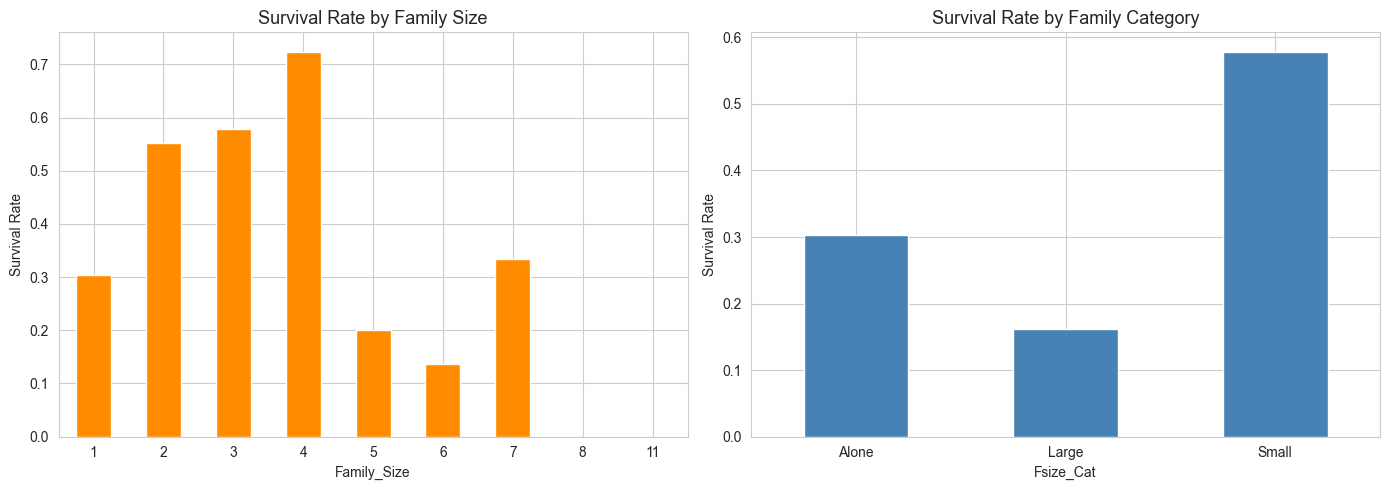

INSIGHT: Solo travelers ~30%, small families ~57%, large families ~16%.
INSIGHT: Large families likely couldn't coordinate getting everyone to a lifeboat.


In [17]:
data_df['Family_Size'] = data_df['SibSp'] + data_df['Parch'] + 1

def fsize_cat(n):
    if n == 1:   return 'Alone'
    elif n < 5:  return 'Small'
    else:        return 'Large'

data_df['Fsize_Cat'] = data_df['Family_Size'].apply(fsize_cat)

train_view = data_df[:len(train_df)].copy()
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

train_view.groupby('Family_Size')['Survived'].mean().plot(kind='bar', ax=axes[0], color='darkorange', rot=0)
axes[0].set_title('Survival Rate by Family Size', fontsize=13)
axes[0].set_ylabel('Survival Rate')

train_view.groupby('Fsize_Cat')['Survived'].mean().plot(kind='bar', ax=axes[1], color='steelblue', rot=0)
axes[1].set_title('Survival Rate by Family Category', fontsize=13)
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

print("INSIGHT: Solo travelers ~30%, small families ~57%, large families ~16%.")
print("INSIGHT: Large families likely couldn't coordinate getting everyone to a lifeboat.")

### 4.4 Family & Group Survival Rate

**Why this is the most powerful engineered feature:**  
If we know a family member or travel companion survived, the passenger was more likely to survive too — they helped each other. This leaks survival signal from the training set forward.

**Algorithm:**
1. Group by last name + fare (proxy for same family paying together)
2. For groups > 1: if any member survived → set 1.0, if all died → set 0.0, unknown → 0.5 (mean rate)
3. Repeat using Ticket number to catch non-family travel companions

In [18]:
data_df['Last_Name'] = data_df['Name'].apply(lambda x: x.split(',')[0].strip())
data_df['Fare']      = data_df['Fare'].fillna(data_df['Fare'].median())

MEAN_SURVIVAL           = round(train_df['Survived'].mean(), 4)
data_df['Family_Survival'] = MEAN_SURVIVAL

# Pass 1: families (same last name + same fare)
for _, grp in data_df.groupby(['Last_Name', 'Fare']):
    if len(grp) > 1:
        for idx, row in grp.iterrows():
            others = grp.drop(idx)
            smax   = others['Survived'].max()
            smin   = others['Survived'].min()
            pid    = row['PassengerId']
            if smax == 1.0:
                data_df.loc[data_df['PassengerId'] == pid, 'Family_Survival'] = 1.0
            elif smin == 0.0:
                data_df.loc[data_df['PassengerId'] == pid, 'Family_Survival'] = 0.0

# Pass 2: travel companions (same ticket)
for _, grp in data_df.groupby('Ticket'):
    if len(grp) > 1:
        for idx, row in grp.iterrows():
            if row['Family_Survival'] in [0.0, MEAN_SURVIVAL]:
                others = grp.drop(idx)
                smax   = others['Survived'].max()
                smin   = others['Survived'].min()
                pid    = row['PassengerId']
                if smax == 1.0:
                    data_df.loc[data_df['PassengerId'] == pid, 'Family_Survival'] = 1.0
                elif smin == 0.0:
                    data_df.loc[data_df['PassengerId'] == pid, 'Family_Survival'] = 0.0

n_with_info = (data_df['Family_Survival'] != MEAN_SURVIVAL).sum()
print(f'Passengers with family/group survival info: {n_with_info} / {len(data_df)}')
print("INSIGHT: Without this feature scores typically cap at ~79%. With it, 82%+ becomes reachable.")

Passengers with family/group survival info: 546 / 1309
INSIGHT: Without this feature scores typically cap at ~79%. With it, 82%+ becomes reachable.


### 4.5 Fare Bins and Age Bins

**Why bin continuous variables?**  
Raw continuous values can be noisy — a fare of £7.25 vs £7.50 is meaningless. Binning reduces noise and lets the model learn threshold effects cleanly.

**Why `pd.qcut` (quantile-based)?**  
Each bin gets roughly equal passenger counts, avoiding empty bins or over-representation.

In [19]:
label = LabelEncoder()

# Fare bins (5 quantile groups)
data_df['FareBin']      = pd.qcut(data_df['Fare'], 5)
data_df['FareBin_Code'] = label.fit_transform(data_df['FareBin'])

# Age bins (4 quantile groups)
data_df['AgeBin']      = pd.qcut(data_df['Age'], 4)
data_df['AgeBin_Code'] = label.fit_transform(data_df['AgeBin'])

# Child and Senior binary flags
# Children (<18) and seniors (>70) showed distinct survival patterns in EDA
data_df['Child']  = (data_df['Age'] < 18).astype(int)
data_df['Senior'] = (data_df['Age'] > 70).astype(int)

# Name length — proxy for social class (longer names = more titles/honorifics = higher class)
data_df['Name_Length'] = data_df['Name'].str.replace('[^a-zA-Z]', '', regex=True).str.len()

# Ticket frequency — passengers sharing a ticket traveled together
data_df['Ticket_Frequency'] = data_df.groupby('Ticket')['Ticket'].transform('count')

# Encode Sex: female=1, male=0
data_df['Sex'] = (data_df['Sex'] == 'female').astype(int)

# Encode Title and Family Size Category as ordinal numbers
title_num = {'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Other': 4, 'Royal': 5, 'Master': 6}
fsize_num = {'Alone': 3, 'Small': 2, 'Large': 1}
data_df['Title_Code'] = data_df['Title'].map(title_num).fillna(4).astype(int)
data_df['Fsize_Code'] = data_df['Fsize_Cat'].map(fsize_num)

print('All engineered features created successfully.')
new_cols = ['FareBin_Code', 'AgeBin_Code', 'Child', 'Senior',
            'Name_Length', 'Ticket_Frequency', 'Title_Code', 'Fsize_Code', 'Family_Survival']
data_df[new_cols].head()

All engineered features created successfully.


,FareBin_Code,AgeBin_Code,Child,Senior,Name_Length,Ticket_Frequency,Title_Code,Fsize_Code,Family_Survival
0,0,0,0,0,18,1,1,2,0.3838
1,4,3,0,0,41,2,3,2,0.3838
2,1,1,0,0,18,1,2,3,0.3838
3,4,2,0,0,34,2,3,2,0.0000
4,1,2,0,0,19,1,1,3,0.3838


### 4.6 Visualizing All Engineered Features vs Survival

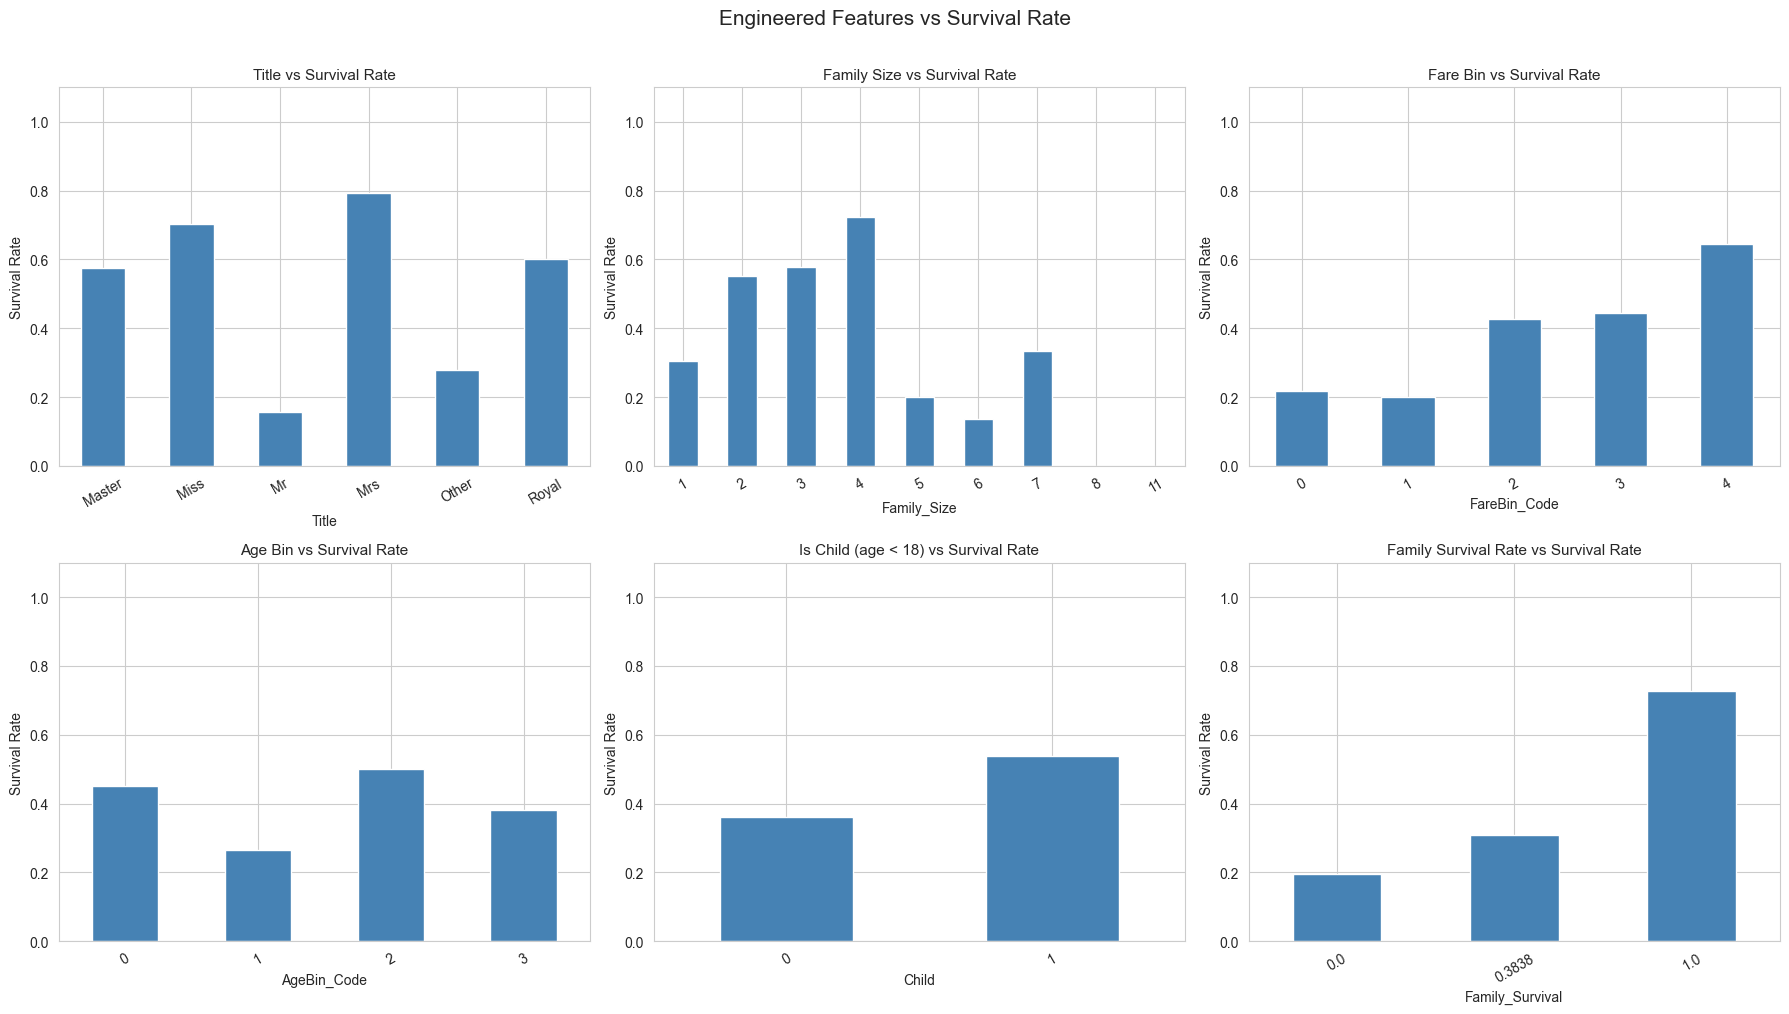

In [20]:
train_fe = data_df[:len(train_df)].copy()

features_to_plot = [
    ('Title', 'Title'),
    ('Family_Size', 'Family Size'),
    ('FareBin_Code', 'Fare Bin'),
    ('AgeBin_Code', 'Age Bin'),
    ('Child', 'Is Child (age < 18)'),
    ('Family_Survival', 'Family Survival Rate'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, title) in zip(axes, features_to_plot):
    surv_rate = train_fe.groupby(col)['Survived'].mean()
    surv_rate.plot(kind='bar', ax=ax, rot=30, color='steelblue')
    ax.set_title(f'{title} vs Survival Rate', fontsize=11)
    ax.set_ylabel('Survival Rate')
    ax.set_ylim(0, 1.1)

plt.suptitle('Engineered Features vs Survival Rate', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 5. Prepare Final Feature Set

In [21]:
FEATURES = [
    'Pclass', 'Sex', 'Family_Size', 'Fsize_Code',
    'Family_Survival', 'FareBin_Code', 'AgeBin_Code',
    'Title_Code', 'Child', 'Senior', 'Name_Length', 'Ticket_Frequency'
]

train_final = data_df[:len(train_df)].copy()
test_final  = data_df[len(train_df):].copy()

X      = train_final[FEATURES]
y      = train_final['Survived']
X_test = test_final[FEATURES]

print(f'Train: {X.shape} | Test: {X_test.shape}')
print(f'Features: {FEATURES}')

Train: (891, 12) | Test: (418, 12)
Features: ['Pclass', 'Sex', 'Family_Size', 'Fsize_Code', 'Family_Survival', 'FareBin_Code', 'AgeBin_Code', 'Title_Code', 'Child', 'Senior', 'Name_Length', 'Ticket_Frequency']
